In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [4]:
image_cut = image[55:155, 0:1800]
image_error_cut = image_error[55:155, 0:1800]

Text(0.5, 0, 'wavelenght')

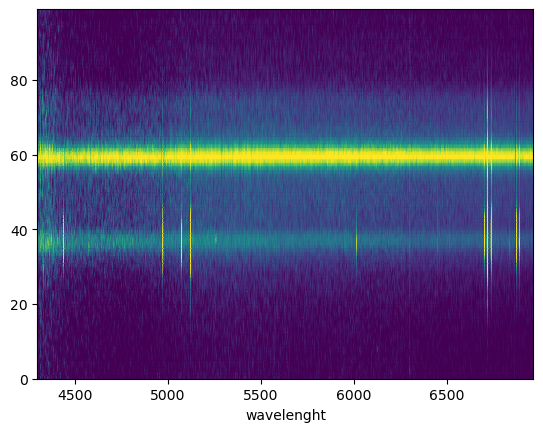

In [5]:
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

## Redshift or the lines in air

In [6]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

In [7]:
l_HA

6719.1994

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


Text(0.5, 0, 'wavelenght')

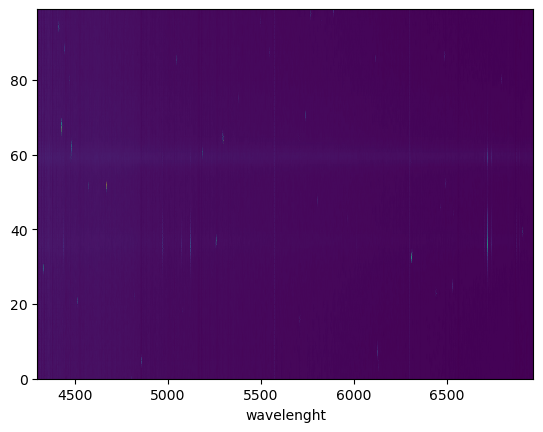

In [8]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[55:155, 0:1800]

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

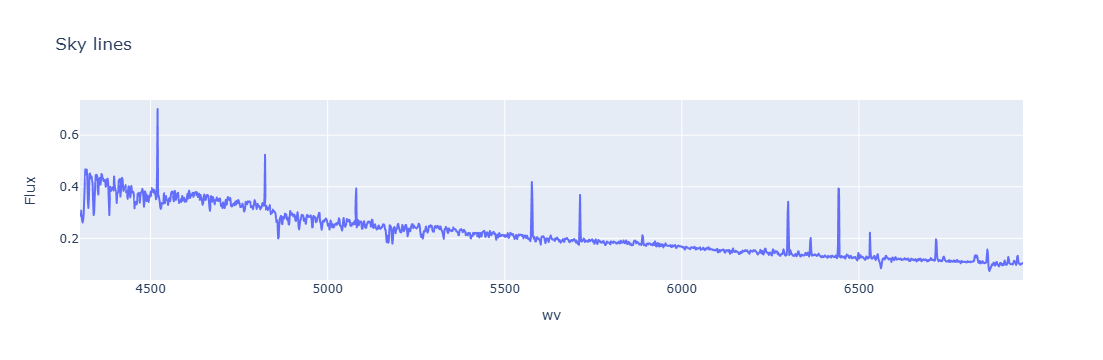

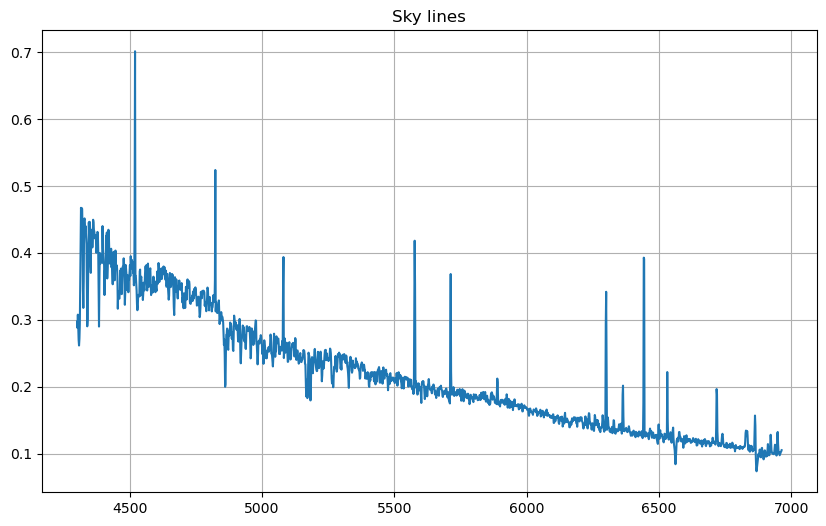

In [9]:
mask_sky = (y > 15)*(y < 25)
image_sky = image_cut2[mask_sky, :]
radial_profile_sky = np.mean(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wavelenghts, radial_profile_sky)
#x_interval = np.arange(4300, 4300+1800*1.48, 250)
#plt.xticks(x_interval)
plt.grid()
plt.title(r'Sky lines')

import plotly.express as px

fig = px.line(x = wavelenghts, y = radial_profile_sky, labels={'x':'wv', 'y':'Flux'}, title = "Sky lines")# x="wv", y="Flux", title="Sky lines")
#fig.update_layout(
#    xaxis=dict(showgrid=False),
#    yaxis=dict(showgrid=False)
#)

fig.show()

## H$\alpha$

[0.00199995 0.00200032 0.00201779 0.00201654 0.00201868 0.00203275
 0.00201366 0.0020099  0.00203024 0.00205202 0.00203898 0.00203963
 0.0020376  0.00202088 0.00204492 0.00207772 0.00209198 0.00213538
 0.00217228 0.00222195 0.00228526 0.00227263 0.00223645 0.00223431
 0.00227714 0.00233891 0.00243793 0.0025702  0.00272596 0.00295238
 0.00321087 0.0034536  0.00376587 0.00418121 0.00487717 0.00576524
 0.00630024 0.00602531 0.00534679 0.00486246 0.00457629 0.00432444
 0.00415814 0.00401824 0.00374189 0.00338401 0.00306796 0.0028266
 0.00268036 0.00262352 0.00260347 0.00260557 0.00261961 0.00266591
 0.00274526 0.00279248 0.00288641 0.00317191 0.00381031 0.00446422
 0.00446514 0.00390629 0.00329925 0.0029124  0.00273268 0.00260608
 0.00251682 0.00248584 0.00246874 0.00246579 0.00251553 0.00255168
 0.00257687 0.0025161  0.00246694 0.00242411 0.0023613  0.00230715
 0.00224925 0.00217891 0.00216434 0.00215001 0.00212812 0.00213713
 0.00213505 0.00209866 0.00210264 0.00207148 0.00208502 0.00206

Text(0.5, 1.0, 'H$\\alpha$')

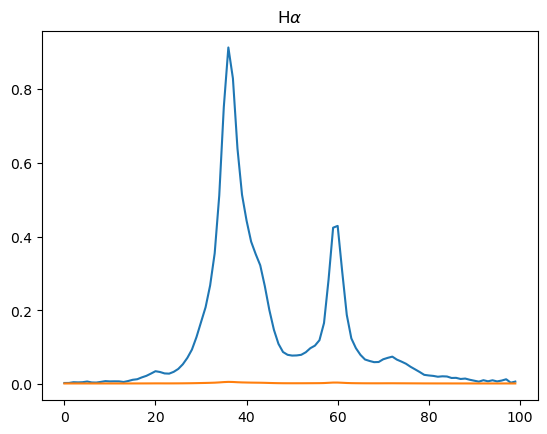

In [22]:
#Ogni punto del flusso è il risultato della media di 20 lunghezze d'onda, otteniamo l'errore come std della media
mask_HA = (wavelenghts > l_HA-10)*(wavelenghts < l_HA+10)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.mean(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))/image_error_HA.shape[1]
print(radial_profile_error_HA)

x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [11]:
np.sqrt(np.sum(image_error_HA[0]**2))/len(image_error_HA[0])
image_error_HA.shape[1]

13

In [12]:
image_error_HA[:, 7]

array([0.00719964, 0.00716636, 0.00713236, 0.00721354, 0.00737467,
       0.00749214, 0.0075564 , 0.00730903, 0.00728604, 0.00769035,
       0.00758607, 0.00747766, 0.00744139, 0.00739624, 0.00749539,
       0.0077408 , 0.00786305, 0.00766336, 0.00761351, 0.00779215,
       0.00789512, 0.00802868, 0.0082304 , 0.00853798, 0.00883493,
       0.00907985, 0.00946892, 0.01010476, 0.01071307, 0.01151189,
       0.01300277, 0.01381353, 0.0147665 , 0.01698969, 0.0206352 ,
       0.02544307, 0.02793511, 0.02587998, 0.02216176, 0.02009732,
       0.01946655, 0.01849345, 0.01779391, 0.01720328, 0.01595465,
       0.01417364, 0.01242753, 0.01135235, 0.0105706 , 0.01016033,
       0.0100691 , 0.01018346, 0.01000953, 0.01022657, 0.01087661,
       0.01123802, 0.01182259, 0.01355989, 0.01698731, 0.02066084,
       0.02059019, 0.01726205, 0.01386188, 0.01178729, 0.01118319,
       0.010574  , 0.00994297, 0.00939923, 0.009142  , 0.00897904,
       0.00946809, 0.00920493, 0.00938193, 0.0092591 , 0.00890

In [25]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def sersic_1d_convolved(x, I_e, r_e, n, x_0): #Convolved sersic profile with the psf
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   #The PSF is a gaussian centered in 0!
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, y_err): #chi squared for degree of freedom
    y_model = model_convolved(x, *params)
    return ((1/(len(y)-1))*np.sum((y - y_model** 2 / y_err)** 2))

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (50, 70),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, radial_profile_error_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 4027.0353906464493
differential_evolution step 2: f(x)= 4027.0353906464493
differential_evolution step 3: f(x)= 1993.3602484567045
differential_evolution step 4: f(x)= 1740.2483512053486
differential_evolution step 5: f(x)= 1253.88637874604
differential_evolution step 6: f(x)= 1253.88637874604
differential_evolution step 7: f(x)= 1253.88637874604
differential_evolution step 8: f(x)= 1253.88637874604
differential_evolution step 9: f(x)= 1052.1829500461517
differential_evolution step 10: f(x)= 1052.1829500461517
differential_evolution step 11: f(x)= 1052.1829500461517
differential_evolution step 12: f(x)= 662.6875564617166
differential_evolution step 13: f(x)= 662.6875564617166
differential_evolution step 14: f(x)= 662.6875564617166
differential_evolution step 15: f(x)= 662.6875564617166
differential_evolution step 16: f(x)= 393.650300965861
differential_evolution step 17: f(x)= 393.650300965861
differential_evolution step 18: f(x)= 393.650300965861
d

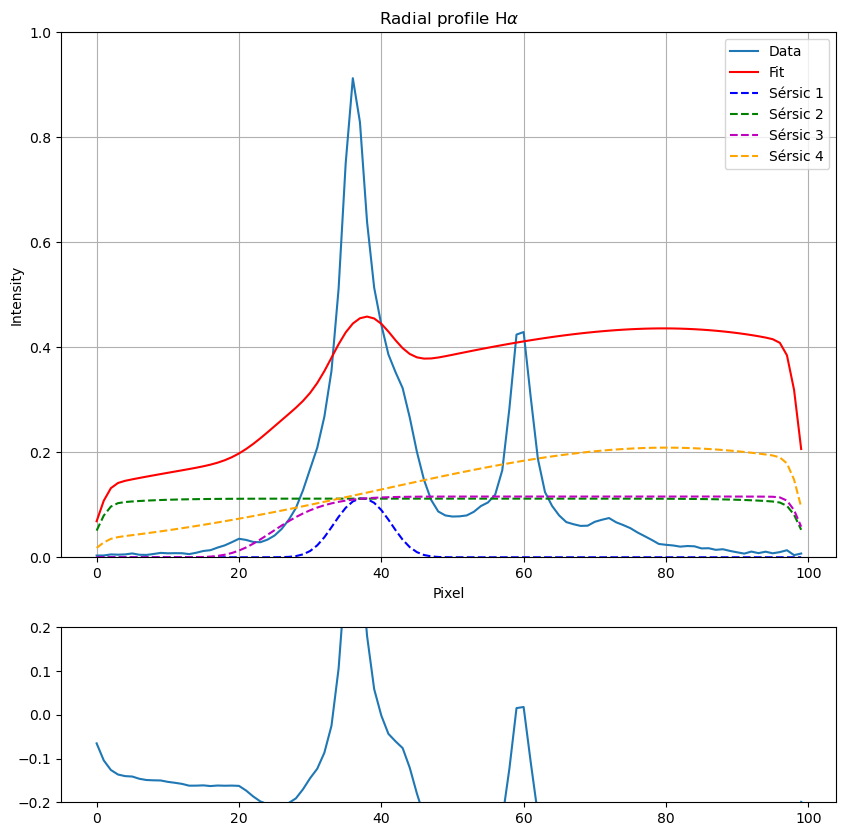

In [24]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

plt.savefig('Radial_profile_Halpha_kernel')

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

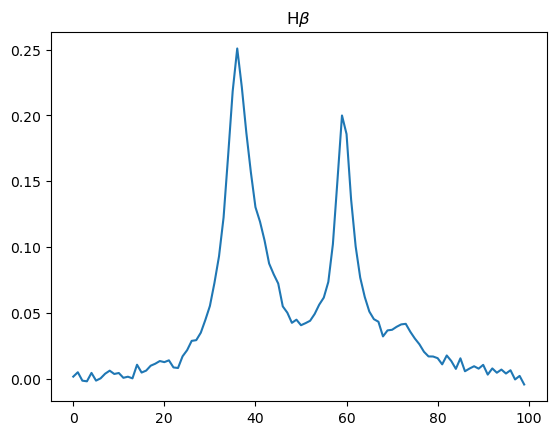

In [11]:
mask_HB = (wavelenghts > l_HB-10)*(wavelenghts < l_HB+10)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.mean(image_HB, axis = 1)
radial_profile_error_HB = (np.std(image_error_HB, axis = 1))/np.sqrt(20)

x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [12]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 20),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 0.1),
    (2, 20),
    (0.1, 10),
    (40, 50),

    (0, 0.1),
    (2, 10),
    (0.1, 50),
    (50, 70),

    (0, 0.1),
    (2, 10),
    (0.1, 50),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 0.6860499034658851
differential_evolution step 2: f(x)= 0.4822839905187197
differential_evolution step 3: f(x)= 0.4822839905187197
differential_evolution step 4: f(x)= 0.15551161952191617
differential_evolution step 5: f(x)= 0.15551161952191617
differential_evolution step 6: f(x)= 0.15551161952191617
differential_evolution step 7: f(x)= 0.12581602703618847
differential_evolution step 8: f(x)= 0.12581602703618847
differential_evolution step 9: f(x)= 0.12581602703618847
differential_evolution step 10: f(x)= 0.12581602703618847
differential_evolution step 11: f(x)= 0.12581602703618847
differential_evolution step 12: f(x)= 0.11190626225121574
differential_evolution step 13: f(x)= 0.09923270248859097
differential_evolution step 14: f(x)= 0.09923270248859097
differential_evolution step 15: f(x)= 0.09923270248859097
differential_evolution step 16: f(x)= 0.09923270248859097
differential_evolution step 17: f(x)= 0.09923270248859097
differential_evolution ste

KeyboardInterrupt: 

In [ ]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_HB, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\beta$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0,1)

ax[1].plot(x_axes, radial_profile_HB - y_fit)
ax[1].set_ylim(-0.2, 0.2)
plt.savefig('Radial_profile_Hbeta_kernel')

## [NII]

In [ ]:
mask_NII = (wavelenghts > l_NII-10)*(wavelenghts < l_NII+10)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.mean(image_NII, axis = 1)
radial_profile_error_NII = (np.std(image_error_HB, axis = 1))/np.sqrt(20)
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [ ]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (50, 70),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)

In [ ]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_NII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [NII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].plot(x_axes, radial_profile_NII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
plt.savefig('Radial_profile_NII_kernel')

## [SII]

In [ ]:
mask_SII = (wavelenghts > l_SII-10)*(wavelenghts < l_SII+10)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.mean(image_SII, axis = 1)
radial_profile_error_SII = (np.std(image_error_HB, axis = 1))/np.sqrt(20)
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [ ]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 20),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 0.1),
    (2, 20),
    (0.1, 10),
    (40, 50),

    (0, 0.1),
    (2, 10),
    (0.1, 50),
    (50, 70),

    (0, 0.1),
    (2, 10),
    (0.1, 50),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)

In [ ]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_SII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [SII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0,1)

ax[1].plot(x_axes, radial_profile_SII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
plt.savefig('Radial_profile_SII_kernel')

## [OIII]

In [ ]:
mask_OIII = (wavelenghts > l_OIII-10)*(wavelenghts < l_OIII+10)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.mean(image_OIII, axis = 1)
radial_error_profile_OIII = (np.std(image_error_HB, axis = 1))/np.sqrt(20)
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [ ]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (2, 20),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 0.1),
    (2, 20),
    (0.1, 10),
    (40, 50),

    (0, 0.1),
    (2, 10),
    (0.1, 50),
    (50, 70),

    (0, 0.1),
    (2, 10),
    (0.1, 50),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)

In [ ]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_OIII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [OIII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].plot(x_axes, radial_profile_OIII - y_fit)
ax[1].set_ylim(-0.2, 0.2)

plt.savefig('Radial_profile_OIII_kernel')